In [1]:
import csv
import numpy as np
from scipy.stats import binned_statistic


In [2]:
def process_scan_to_perimeter(angles_input, distances_input):
    """
    Apply the full cleaning and binning pipeline to a raw LiDAR scan.
    Returns: x_sorted, y_sorted (Cartesian perimeter points, sorted by angle)
    """
    angles_arr = np.array(angles_input)
    distances_arr = np.array(distances_input)

    # Neighbor-based outlier removal (2 passes, window=3, threshold=0.5σ)
    bin_indices = np.round(angles_arr).astype(int) % 360
    per_angle = [[] for _ in range(360)]
    for idx, ang in enumerate(bin_indices):
        per_angle[ang].append(distances_arr[idx])

    window, threshold = 3, 0.5
    for _ in range(2):
        means = np.array([np.mean(a) if a else np.nan for a in per_angle])
        clean_a, clean_d = [], []
        for idx, (ang, dist) in enumerate(zip(bin_indices, distances_arr)):
            nbrs = means[[(ang + i) % 360 for i in range(-window, window + 1)]]
            lm, ls = np.nanmean(nbrs), np.nanstd(nbrs)
            if ls == 0:
                keep = np.abs(dist - lm) < 1e-6
            else:
                keep = np.abs(dist - lm) <= threshold * ls
            if keep:
                clean_a.append(angles_arr[idx])
                clean_d.append(dist)
        angles_arr = np.array(clean_a)
        distances_arr = np.array(clean_d)
        bin_indices = np.round(angles_arr).astype(int) % 360
        per_angle = [[] for _ in range(360)]
        for idx, ang in enumerate(bin_indices):
            per_angle[ang].append(distances_arr[idx])

    # IQR outlier removal per 1° bin
    clean_a, clean_d = [], []
    for ang in range(360):
        mask = (angles_arr >= ang) & (angles_arr < ang + 1)
        dists = distances_arr[mask]
        if len(dists) > 0:
            q1, q3 = np.percentile(dists, 25), np.percentile(dists, 75)
            iqr = q3 - q1
            good = (dists >= q1 - 1.5 * iqr) & (dists <= q3 + 1.5 * iqr)
            clean_a.extend(angles_arr[mask][good])
            clean_d.extend(dists[good])

    # Bin into 360 mean values
    perimeter_r, bin_edges, _ = binned_statistic(
        clean_a, clean_d, statistic='mean', bins=360, range=(0, 360)
    )
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    valid = ~np.isnan(perimeter_r)

    # Global percentile filter (5th–95th)
    all_d = perimeter_r[valid]
    valid[valid] &= (all_d >= np.percentile(all_d, 5)) & (all_d <= np.percentile(all_d, 95))

    bin_angles = bin_centers[valid]
    bin_dists = perimeter_r[valid]
    x = np.cos(np.deg2rad(-bin_angles)) * bin_dists
    y = np.sin(np.deg2rad(-bin_angles)) * bin_dists

    # Sort by angle
    order = np.argsort(np.floor(bin_angles).astype(int))
    return x[order], y[order]


In [3]:
# PROCESS MULTIPLE SCANS IN A LOOP

scan_files_to_process = {
    'scan_1': 'lidar_map_1.csv',
    'scan_2': 'lidar_map_2.csv',
    'scan_3': 'lidar_map_3.csv',
    'scan_4': 'lidar_map_4.csv',  
    'scan_5': 'lidar_map_5.csv',  
    'scan_6': 'lidar_map_6.csv',  
    'scan_7': 'lidar_map_7.csv',  
    'scan_8': 'lidar_map_8.csv',  

}

print(f"Processing {len(scan_files_to_process)} scans...\n")

processed_scans = {}

for scan_id, filename in scan_files_to_process.items():
    try:
        angles_raw = []
        distances_raw = []
        with open(filename, 'r') as f:
            reader = csv.reader(f)
            for row in reader:
                angles_raw.append(float(row[0]))
                distances_raw.append(float(row[1]))
        
        print(f"{scan_id}: Loaded {len(angles_raw)} rays")
        
        x_perimeter, y_perimeter = process_scan_to_perimeter(angles_raw, distances_raw)
        
        processed_scans[scan_id] = {
            'x': x_perimeter,
            'y': y_perimeter,
            'num_points': len(x_perimeter)
        }
        print(f"Filtered to {len(x_perimeter)} perimeter points\n")
        
    except FileNotFoundError:
        print(f"{scan_id}: File '{filename}' not found\n")

Processing 8 scans...

scan_1: Loaded 7600 rays
Filtered to 177 perimeter points

scan_2: Loaded 7500 rays
Filtered to 195 perimeter points

scan_3: Loaded 8050 rays
Filtered to 215 perimeter points

scan_4: Loaded 7900 rays
Filtered to 209 perimeter points

scan_5: Loaded 8100 rays
Filtered to 167 perimeter points

scan_6: Loaded 8350 rays
Filtered to 136 perimeter points

scan_7: Loaded 8000 rays
Filtered to 172 perimeter points

scan_8: Loaded 7700 rays
Filtered to 170 perimeter points



In [4]:
from scipy.optimize import differential_evolution
from scipy.spatial import cKDTree
import numpy as np
import matplotlib.pyplot as plt
from skimage import measure
from skimage.morphology import binary_dilation, binary_closing, binary_erosion, disk, square
from scipy.ndimage import binary_fill_holes
from shapely.geometry import Polygon, MultiPolygon
from shapely.validation import make_valid

def extract_line_segments(x, y, angle_gap_thresh=2.0, min_len=3):
    if len(x) < 2:
        return [(x, y)]
    angles = np.degrees(np.arctan2(y, x)) % 360
    diffs = (np.diff(angles) + 180) % 360 - 180
    breaks = np.where(np.abs(diffs) > angle_gap_thresh)[0] + 1
    segs, start = [], 0
    for b in breaks:
        if b - start >= min_len:
            segs.append((x[start:b], y[start:b]))
        start = b
    if len(x) - start >= min_len:
        segs.append((x[start:], y[start:]))
    return segs

def to_array(seg):
    if isinstance(seg, np.ndarray) and seg.ndim == 2:
        return seg
    return np.column_stack(seg)

def stack(segs):
    return np.vstack([to_array(s) for s in segs])

def apply_transform(pts, theta, tx, ty):
    c, s = np.cos(theta), np.sin(theta)
    R = np.array([[c, -s], [s, c]])
    return pts @ R.T + [tx, ty]

def align_to_map(pts_src, pts_map):
    tree = cKDTree(pts_map)
    def cost(params):
        theta_rad, tx, ty = params
        c, s = np.cos(theta_rad), np.sin(theta_rad)
        R = np.array([[c, -s], [s, c]])
        dists, _ = tree.query(pts_src @ R.T + [tx, ty])
        return np.mean(dists)
    bounds = [(-np.radians(30), np.radians(30)), (-5000, 5000), (-5000, 5000)]
    res = differential_evolution(cost, bounds, seed=42, maxiter=1000, tol=0.005, popsize=15)
    return res.x[0], res.x[1], res.x[2], res.fun

def overlap_score(pts_a, pts_b, radius=200):
    tree = cKDTree(pts_b)
    dists, _ = tree.query(pts_a, distance_upper_bound=radius)
    return (dists < radius).sum()

print("Extracting segments...")
scan_segments = {}
for scan_id, data in processed_scans.items():
    segs = extract_line_segments(data['x'], data['y'])
    scan_segments[scan_id] = segs
    print(f"  {scan_id}: {len(segs)} segments, {sum(len(s[0]) for s in segs)} points")

scan_ids = list(scan_segments.keys())

print("\nIncremental alignment...")
global_segments = {scan_ids[0]: scan_segments[scan_ids[0]]}
global_pts      = stack(scan_segments[scan_ids[0]])
transforms      = {scan_ids[0]: (0.0, 0.0, 0.0)}
residuals       = {scan_ids[0]: 0.0}

for scan_id in scan_ids[1:]:
    pts_src = stack(scan_segments[scan_id])
    theta_rad, tx, ty, residual = align_to_map(pts_src, global_pts)
    theta_deg = np.degrees(theta_rad)
    aligned_segs = [apply_transform(to_array(seg), theta_rad, tx, ty)
                    for seg in scan_segments[scan_id]]
    global_segments[scan_id] = aligned_segs
    global_pts = np.vstack([global_pts, stack(aligned_segs)])
    transforms[scan_id] = (theta_deg, tx, ty)
    residuals[scan_id]  = residual
    print(f"  {scan_id}: θ={theta_deg:+.2f}°  tx={tx:+.0f}  ty={ty:+.0f}  residual={residual:.1f} mm")

print("\nComputing overlap scores...")
aligned_pts = {sid: stack(global_segments[sid]) for sid in scan_ids}

residual_thresh = 100   # mm — above this = bad alignment
min_pts         = 50    # fewer points = too sparse to trust
min_overlap     = 50    # fewer shared points with any neighbor = isolated scan

good_scan_ids = [scan_ids[0]]

for sid in scan_ids[1:]:
    pts   = aligned_pts[sid]
    n_pts = len(pts)
    res   = residuals[sid]

    # Best overlap with any other scan
    best_overlap = max(overlap_score(pts, aligned_pts[other])
                       for other in scan_ids if other != sid)

    if n_pts < min_pts:
        print(f"  EXCLUDED {sid}: too few points ({n_pts})")
    elif res > residual_thresh:
        print(f"  EXCLUDED {sid}: high residual ({res:.1f} mm)")
    elif best_overlap < min_overlap:
        print(f"  EXCLUDED {sid}: isolated, best overlap={best_overlap} pts")
    else:
        print(f"  OK       {sid}: {n_pts} pts, residual={res:.1f} mm, overlap={best_overlap}")
        good_scan_ids.append(sid)

print(f"\nUsing {len(good_scan_ids)}/{len(scan_ids)} scans: {good_scan_ids}")

print("\nGraph-based re-alignment...")
for sid in good_scan_ids[1:]:
    pts = aligned_pts[sid]
    best_score, best_neighbor = 0, None
    for other in good_scan_ids:
        if other == sid:
            continue
        score = overlap_score(pts, aligned_pts[other])
        if score > best_score:
            best_score, best_neighbor = score, other

    # Only re-align if a better neighbor than scan_1 exists
    if best_neighbor and best_neighbor != good_scan_ids[0]:
        print(f"  Re-aligning {sid} → {best_neighbor} ({best_score} overlap pts)")
        pts_src = stack(scan_segments[sid])
        theta_rad, tx, ty, residual = align_to_map(pts_src, aligned_pts[best_neighbor])
        theta_deg = np.degrees(theta_rad)
        aligned_segs = [apply_transform(to_array(seg), theta_rad, tx, ty)
                        for seg in scan_segments[sid]]
        global_segments[sid] = aligned_segs
        aligned_pts[sid]     = stack(aligned_segs)
        transforms[sid]      = (theta_deg, tx, ty)
        print(f"    θ={theta_deg:+.2f}°  tx={tx:+.0f}  ty={ty:+.0f}  residual={residual:.1f} mm")


Extracting segments...
  scan_1: 16 segments, 171 points
  scan_2: 10 segments, 190 points
  scan_3: 11 segments, 205 points
  scan_4: 12 segments, 206 points
  scan_5: 14 segments, 164 points
  scan_6: 13 segments, 127 points
  scan_7: 13 segments, 164 points
  scan_8: 9 segments, 161 points

Incremental alignment...
  scan_2: θ=+3.52°  tx=+1495  ty=+55  residual=131.0 mm
  scan_3: θ=+1.80°  tx=+1412  ty=+676  residual=48.5 mm
  scan_4: θ=+2.53°  tx=+2235  ty=+267  residual=46.0 mm
  scan_5: θ=+0.36°  tx=+2925  ty=-457  residual=38.4 mm
  scan_6: θ=+3.19°  tx=+778  ty=-1991  residual=71.2 mm
  scan_7: θ=-1.01°  tx=+798  ty=-2501  residual=46.6 mm
  scan_8: θ=+0.67°  tx=-659  ty=+1886  residual=68.4 mm

Computing overlap scores...
  EXCLUDED scan_2: high residual (131.0 mm)
  OK       scan_3: 205 pts, residual=48.5 mm, overlap=185
  OK       scan_4: 206 pts, residual=46.0 mm, overlap=193
  OK       scan_5: 164 pts, residual=38.4 mm, overlap=138
  OK       scan_6: 127 pts, residual=71.2

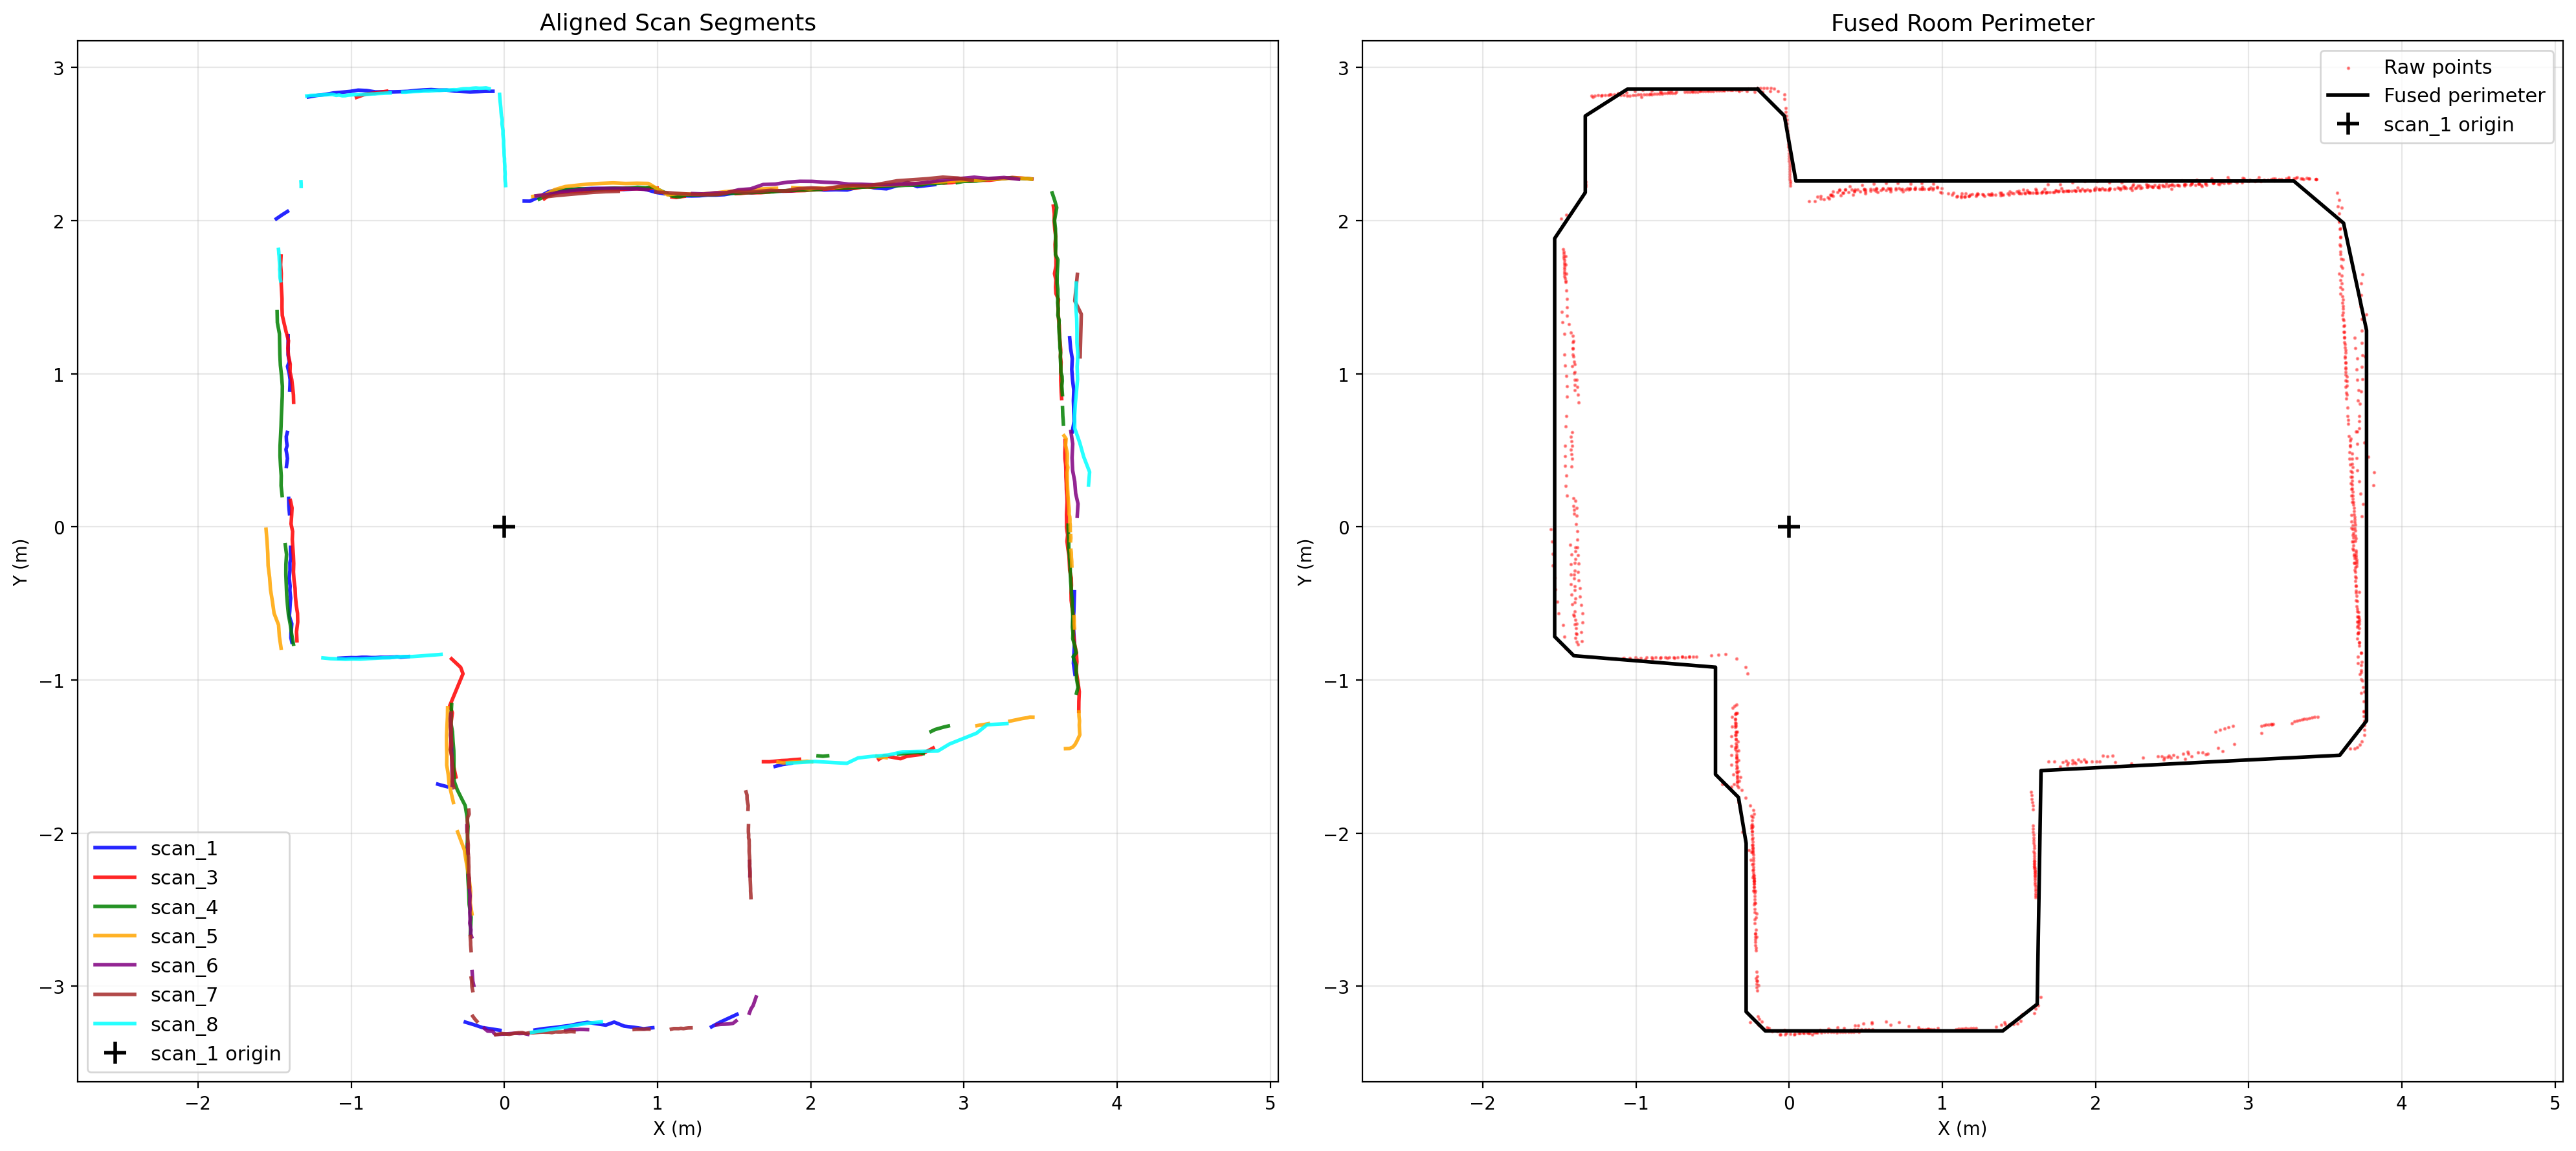

Scans used    : ['scan_1', 'scan_3', 'scan_4', 'scan_5', 'scan_6', 'scan_7', 'scan_8']
Contours found: 1
Perimeter     : 21.45 m
Area          : 23.34 m²


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(20, 9), dpi=200)

# Left: Aligned Scan Segments
for idx, sid in enumerate(good_scan_ids):
    color = ['blue', 'red', 'green', 'orange', 'purple', 'brown', 'cyan', 'magenta'][idx % 8]
    for i, seg in enumerate(global_segments[sid]):
        pts = to_array(seg) / 1000.0  # mm to m
        axes[0].plot(pts[:, 0], pts[:, 1], '-', color=color, lw=2, alpha=0.85, label=sid if i == 0 else '')
axes[0].plot(0, 0, 'k+', markersize=12, markeredgewidth=2, label='scan_1 origin')
axes[0].set_aspect('equal', adjustable='datalim')
axes[0].autoscale(enable=True)
axes[0].grid(True, alpha=0.3)
axes[0].legend(fontsize=11)
axes[0].set_title('Aligned Scan Segments', fontsize=13)
axes[0].set_xlabel('X (m)')
axes[0].set_ylabel('Y (m)')

# Right: Fused Room Perimeter
all_pts = np.vstack([aligned_pts[sid] for sid in good_scan_ids])
resolution  = 50
disk_dilate = 2
disk_close  = 10
padding     = 15
x, y = all_pts[:, 0], all_pts[:, 1]
x_min = x.min() - padding * resolution
y_min = y.min() - padding * resolution
cols = ((x - x_min) / resolution).astype(int)
rows = ((y - y_min) / resolution).astype(int)
n_rows = rows.max() + 2 * padding
n_cols = cols.max() + 2 * padding
grid   = np.zeros((n_rows, n_cols), dtype=bool)
grid[rows, cols] = True
dilated  = binary_dilation(grid,   disk(disk_dilate))
closed   = binary_closing(dilated, square(disk_close * 2 + 1))
filled   = binary_fill_holes(closed)
restored = binary_erosion(filled,  square(disk_dilate * 2 + 1))
contours = measure.find_contours(restored.astype(float), level=0.5)
def contour_area(c):
    cx, cy = c[:, 1], c[:, 0]
    return 0.5 * abs(np.dot(cx, np.roll(cy, 1)) - np.dot(cy, np.roll(cx, 1)))
outer    = max(contours, key=contour_area)
outer_mm = outer[:, ::-1] * resolution + [x_min, y_min]
outer_m  = outer_mm / 1000.0  # convert to meters
poly = Polygon(outer_mm)
poly = make_valid(poly)
if poly.geom_type == 'MultiPolygon':
    poly = max(poly.geoms, key=lambda p: p.area)
poly = poly.simplify(tolerance=resolution * 1.5, preserve_topology=True)
x_s, y_s = (np.array(poly.exterior.xy[0]) / 1000.0, np.array(poly.exterior.xy[1]) / 1000.0)
axes[1].scatter(all_pts[:, 0] / 1000.0, all_pts[:, 1] / 1000.0, s=1, color='red', alpha=0.4, label='Raw points')
axes[1].plot(x_s, y_s, 'k-', lw=2, label='Fused perimeter')
axes[1].plot(0, 0, 'k+', markersize=12, markeredgewidth=2, label='scan_1 origin')
axes[1].set_aspect('equal', adjustable='datalim')
axes[1].autoscale(enable=True)
axes[1].grid(True, alpha=0.3)
axes[1].legend(fontsize=11)
axes[1].set_title('Fused Room Perimeter', fontsize=13)
axes[1].set_xlabel('X (m)')
axes[1].set_ylabel('Y (m)')
plt.tight_layout()
plt.show()

print(f"Scans used    : {good_scan_ids}")
print(f"Contours found: {len(contours)}")
print(f"Perimeter     : {poly.length/1000:.2f} m")
print(f"Area          : {poly.area/1e6:.2f} m²")


In [6]:
print(poly)

POLYGON ((-205.36887067118641 2858.0924211758265, -1055.3688706711864 2858.0924211758265, -1330.3688706711864 2683.0924211758265, -1330.3688706711864 2183.0924211758265, -1530.3688706711864 1883.0924211758265, -1530.3688706711864 -716.9075788241735, -1405.3688706711864 -841.9075788241735, -480.3688706711864 -916.9075788241735, -480.3688706711864 -1616.9075788241735, -330.3688706711864 -1766.9075788241735, -280.3688706711864 -2066.9075788241735, -280.3688706711864 -3166.9075788241735, -155.36887067118641 -3291.9075788241735, 1394.6311293288136 -3291.9075788241735, 1619.6311293288136 -3116.9075788241735, 1644.6311293288136 -1591.9075788241735, 3594.6311293288136 -1491.9075788241735, 3769.6311293288136 -1266.9075788241735, 3769.6311293288136 1283.0924211758265, 3619.6311293288136 1983.0924211758265, 3294.6311293288136 2258.0924211758265, 44.631129328813586 2258.0924211758265, -30.368870671186414 2683.0924211758265, -205.36887067118641 2858.0924211758265))


In [7]:
# Extract vertices from polygon and convert mm → meters
coords = np.array(poly.exterior.coords)  # (N, 2) in mm
coords_m = coords / 1000.0               # convert to meters

# Build wall segment list: each consecutive pair of vertices is one wall
wall_corner_list = []
for i in range(len(coords_m) - 1):   # last point == first point (closed ring)
    x1, y1 = coords_m[i]
    x2, y2 = coords_m[i + 1]
    wall_corner_list.append([round(x1, 3), round(y1, 3),
                              round(x2, 3), round(y2, 3)])

# Print in the format you want
print("wall_corner_list = [")
for w in wall_corner_list:
    print(f"    {w},")
print("]")


wall_corner_list = [
    [-0.205, 2.858, -1.055, 2.858],
    [-1.055, 2.858, -1.33, 2.683],
    [-1.33, 2.683, -1.33, 2.183],
    [-1.33, 2.183, -1.53, 1.883],
    [-1.53, 1.883, -1.53, -0.717],
    [-1.53, -0.717, -1.405, -0.842],
    [-1.405, -0.842, -0.48, -0.917],
    [-0.48, -0.917, -0.48, -1.617],
    [-0.48, -1.617, -0.33, -1.767],
    [-0.33, -1.767, -0.28, -2.067],
    [-0.28, -2.067, -0.28, -3.167],
    [-0.28, -3.167, -0.155, -3.292],
    [-0.155, -3.292, 1.395, -3.292],
    [1.395, -3.292, 1.62, -3.117],
    [1.62, -3.117, 1.645, -1.592],
    [1.645, -1.592, 3.595, -1.492],
    [3.595, -1.492, 3.77, -1.267],
    [3.77, -1.267, 3.77, 1.283],
    [3.77, 1.283, 3.62, 1.983],
    [3.62, 1.983, 3.295, 2.258],
    [3.295, 2.258, 0.045, 2.258],
    [0.045, 2.258, -0.03, 2.683],
    [-0.03, 2.683, -0.205, 2.858],
]
